INIT

This cell checks whether we are running the notebook from Google Colab or just locally.

In [1]:
# This cell checks whether we are running the notebook from Google Colab or just locally
import sys

if 'google.colab' in sys.modules:
    IN_COLAB = True
    print("Running in Google Colab")
else:
    IN_COLAB = False
    print("Running locally")

Running in Google Colab


In [2]:
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    CORPUS_PATH = '/content/drive/MyDrive/TFM_Colab_IA/data/TFM_Corpus'
    PROJECT_ROOT = '/content/drive/MyDrive/TFM_Colab_IA'
    if PROJECT_ROOT not in sys.path:
        sys.path.append(PROJECT_ROOT)
    print('Running under Google Colab environment...')
else:
    # Set your local path here
    CORPUS_PATH = './TFM_Colab_IA/data/TFM_Corpus'
    print('Running locally...')

from src.dataset_lib import validate_and_correct_label, load_dataset

# Configuración
print(f'[DATASET PATH][{CORPUS_PATH}]')

# List variable specifying the identifiers of the different available sensors and their order
SENSORS_LIST = ['chest', 'waist', 'wrist_L', 'wrist_R']
VALID_CLASSES = ['Drive', 'Serve', 'BackhandRH', 'BackhandTwoH', 'Lob', 'Waiting']
WINDOW_SIZE = 200
FEATURES_PER_SENSOR = 3
N_CHANNELS = len(SENSORS_LIST) * FEATURES_PER_SENSOR

Mounted at /content/drive
Running under Google Colab environment...
[DATASET PATH][/content/drive/MyDrive/TFM_Colab_IA/data/TFM_Corpus]


## EXPERIMENT 1: working with CUSTOM devices data

### 📊 Sensor Data Loading and Visualization

The purpose of this cell is to load a sample of our dataset and visualize the temporal evolution of the sensor readings for different activities. It performs three main tasks:

1. **Dynamic Module Reloading (`importlib.reload`)**:
   When developing library code (like our `dataset_lib.py`) alongside a Jupyter Notebook, the notebook caches the imported modules. We use `importlib.reload()` and re-import the functions to ensure that any recent modifications to our library are immediately reflected in the notebook without needing to restart the kernel.

2. **Loading Specific Sensor Data (`load_sensor_data`)**:
   We extract the raw data and labels directly from a specific CSV file. In this example, we are loading the left wrist sensor (`sensor_wrist_L.csv`) for Participant 1 (`P1`), Session 1 (`S1`). The function reads the 600 features and reshapes them into our defined `WINDOW_SIZE` and `FEATURES_PER_SENSOR`.

3. **Plotting the Signals (`plot_temporal_evolution`)**:
   Finally, we generate a visual representation of the sensor data. The plotting function scans the data for all unique activity labels and creates a dedicated subplot for each one. Each subplot displays the first window (e.g., 200 samples) recorded for that specific activity, allowing us to inspect the raw $X$, $Y$, and $Z$ accelerometer axes.

In [4]:
import os
#import importlib
#importlib.reload(src.dataset_lib)
from src.dataset_lib import load_dataset, load_sensor_data, plot_temporal_evolution

path_custom = [os.path.join(CORPUS_PATH, 'Custom')]
print(SENSORS_LIST)
# load_dataset returns a tuple containing:
# X: Numpy array of shape (n_samples, WINDOW_SIZE, N_CHANNELS) with the sensor data.
# y: Numpy array of shape (n_samples,) with the labels.
# subject_ids: Numpy array of shape (n_samples,) with the subject IDs.
X_c, y_c, subjects_c = load_dataset(path_custom, SENSORS_LIST, VALID_CLASSES, WINDOW_SIZE, FEATURES_PER_SENSOR)

['chest', 'waist', 'wrist_L', 'wrist_R']
	[Loading dataset from /content/drive/MyDrive/TFM_Colab_IA/data/TFM_Corpus/Custom]
		[Processing subject: P1]
			[Processing session: S1]
			[Processing session: S2]
		[Processing subject: P2]
			[Processing session: S1]
			[Processing session: S2]
		[Processing subject: P3]
			[Processing session: S1]
			[Processing session: S2]
		[Processing subject: P4]
			[Processing session: S1]
			[Processing session: S2]
		[Processing subject: P5]
			[Processing session: S1]
			[Processing session: S2]
		[Processing subject: P6]
			[Processing session: S1]
			[Processing session: S2]
		[Processing subject: P7]
			[Processing session: S1]
			[Processing session: S2]
		[Processing subject: P8]
			[Processing session: S1]
			[Processing session: S2]
		[Processing subject: P9]
			[Processing session: S1]
			[Processing session: S2]
		[Processing subject: P10]
			[Processing session: S1]
			[Processing session: S2]
		[Processing subject: P11]
			[Processing se

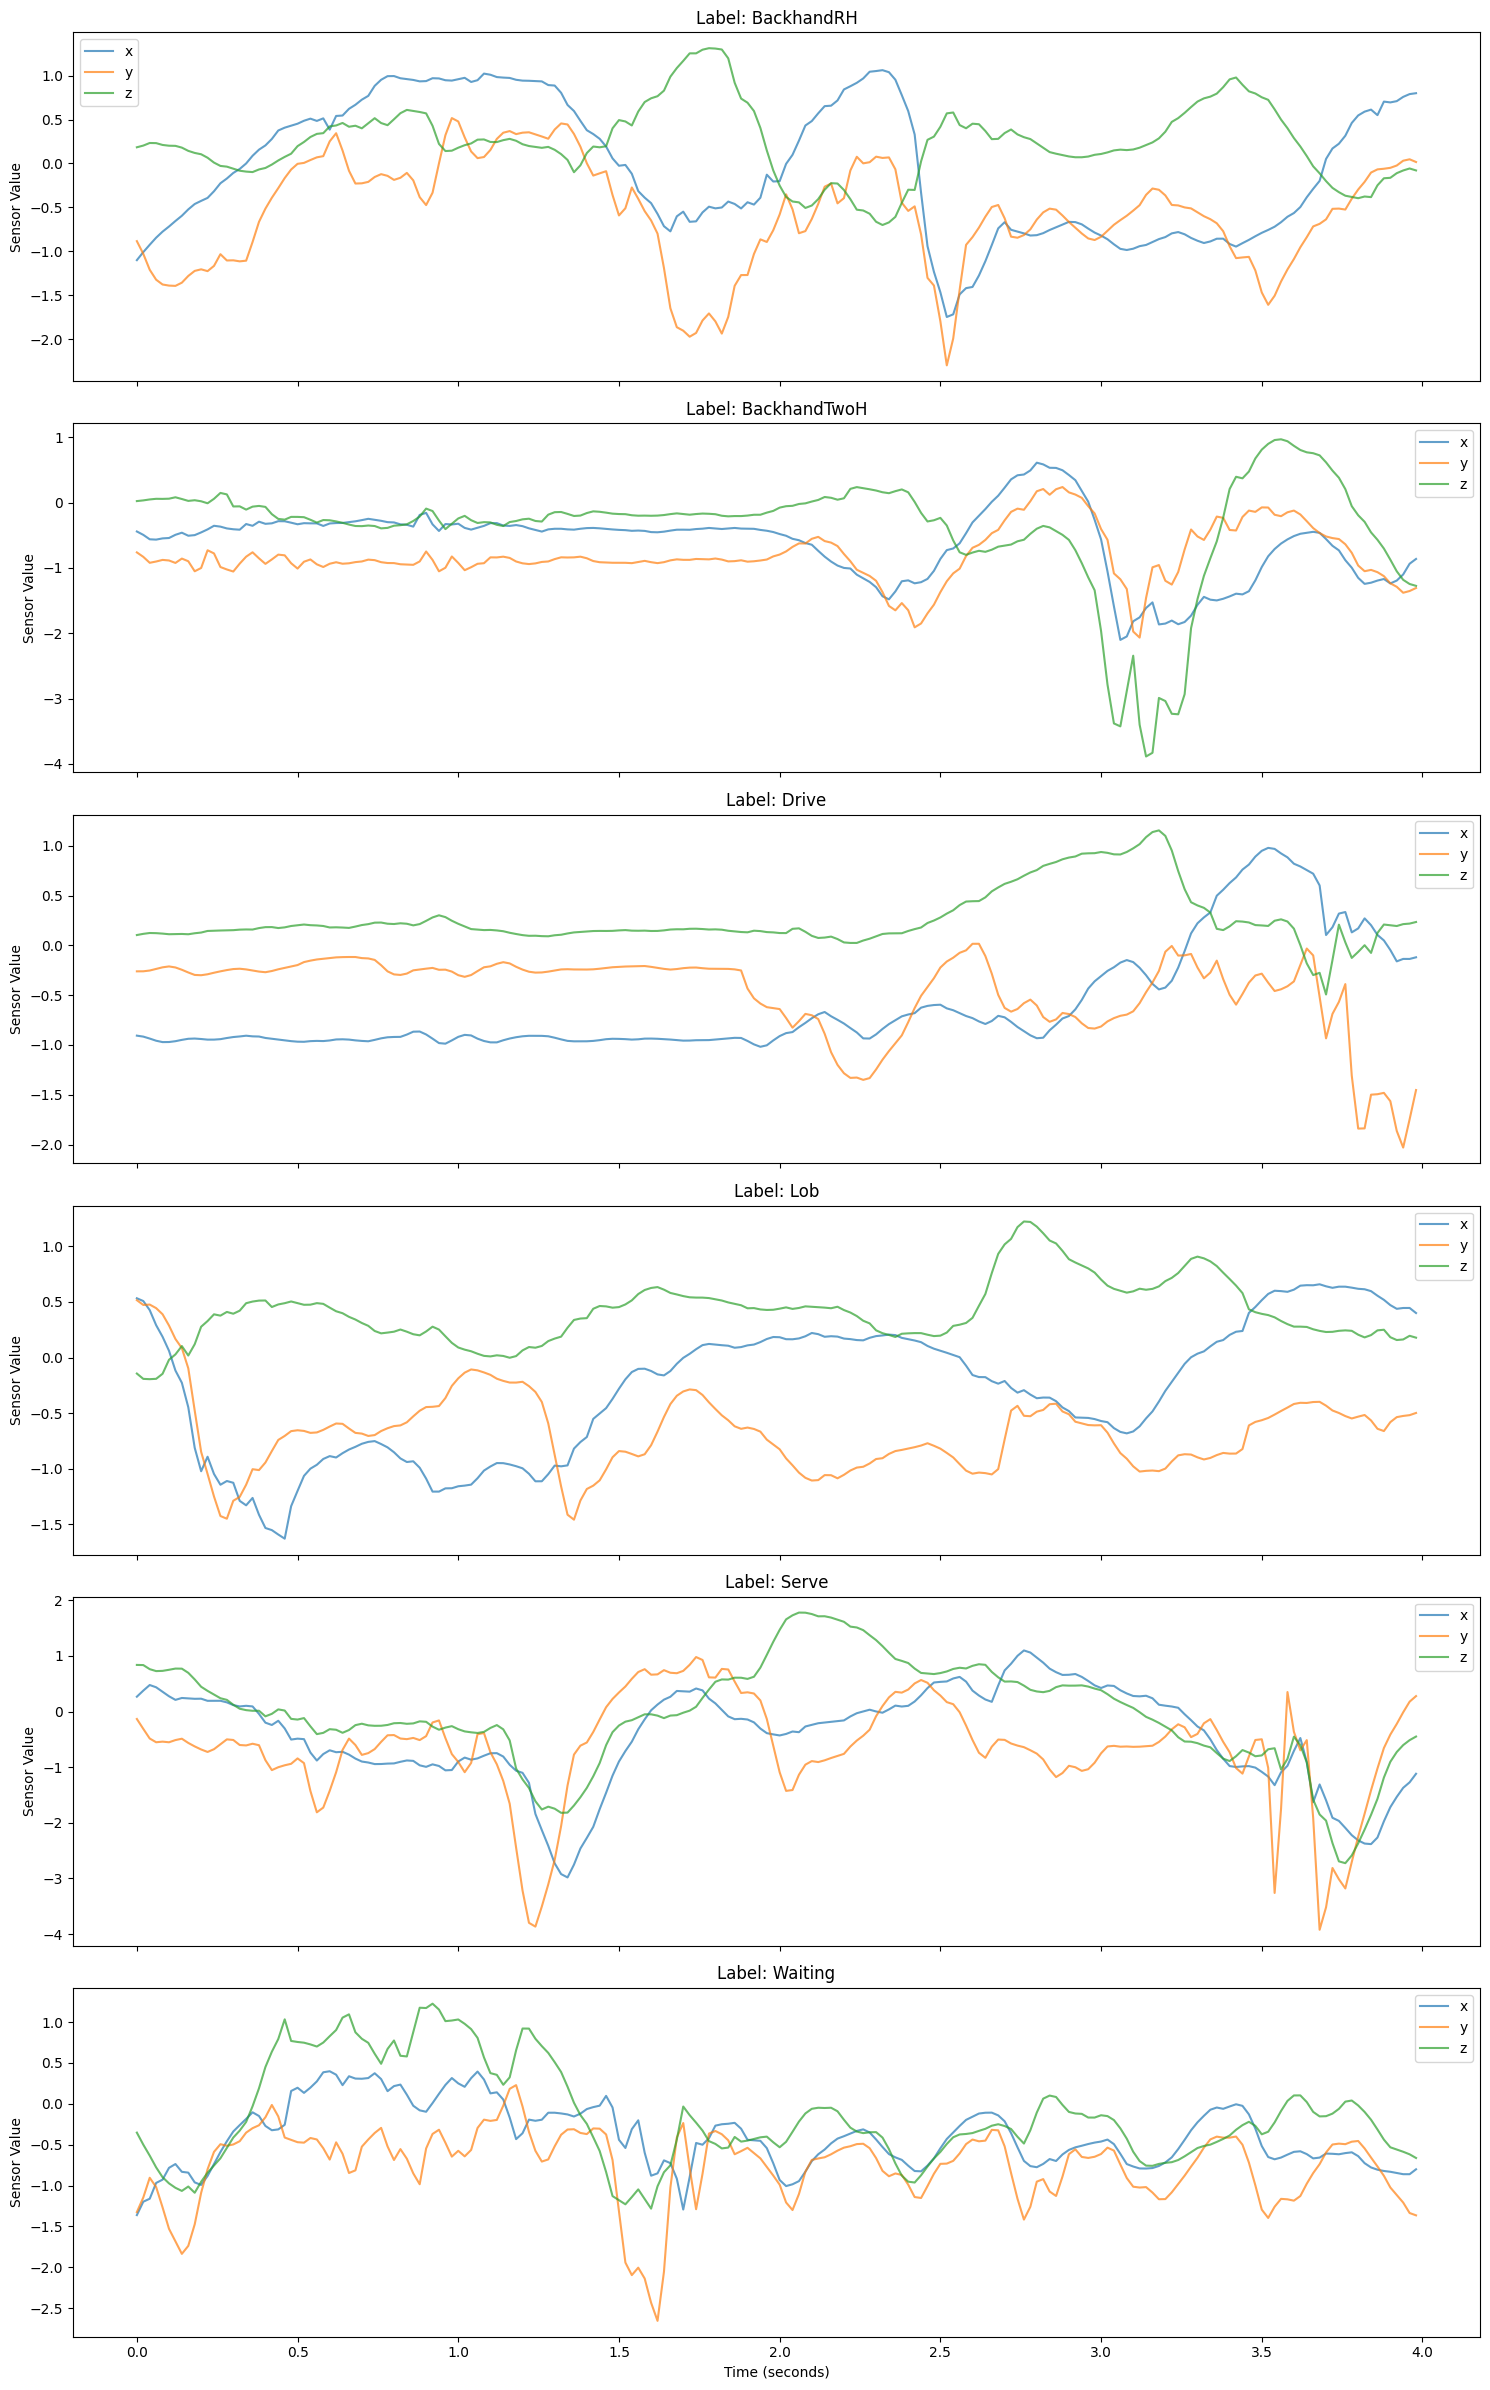

In [5]:
#import importlib
#importlib.reload(src.dataset_lib)
from src.dataset_lib import load_sensor_data, plot_temporal_evolution, compute_functionals  # <--- Obligatorio repetir esto

sample_data, sample_labels = load_sensor_data(file_path='/content/drive/MyDrive/TFM_Colab_IA/data/TFM_Corpus/Custom/P1/S1/sensor_wrist_L.csv',
    window_size=WINDOW_SIZE,
    features_per_sensor=FEATURES_PER_SENSOR)

plot_temporal_evolution(sample_data, sample_labels, window_size=WINDOW_SIZE,
    features_per_sensor=FEATURES_PER_SENSOR,
    axis_names=['x', 'y', 'z'])

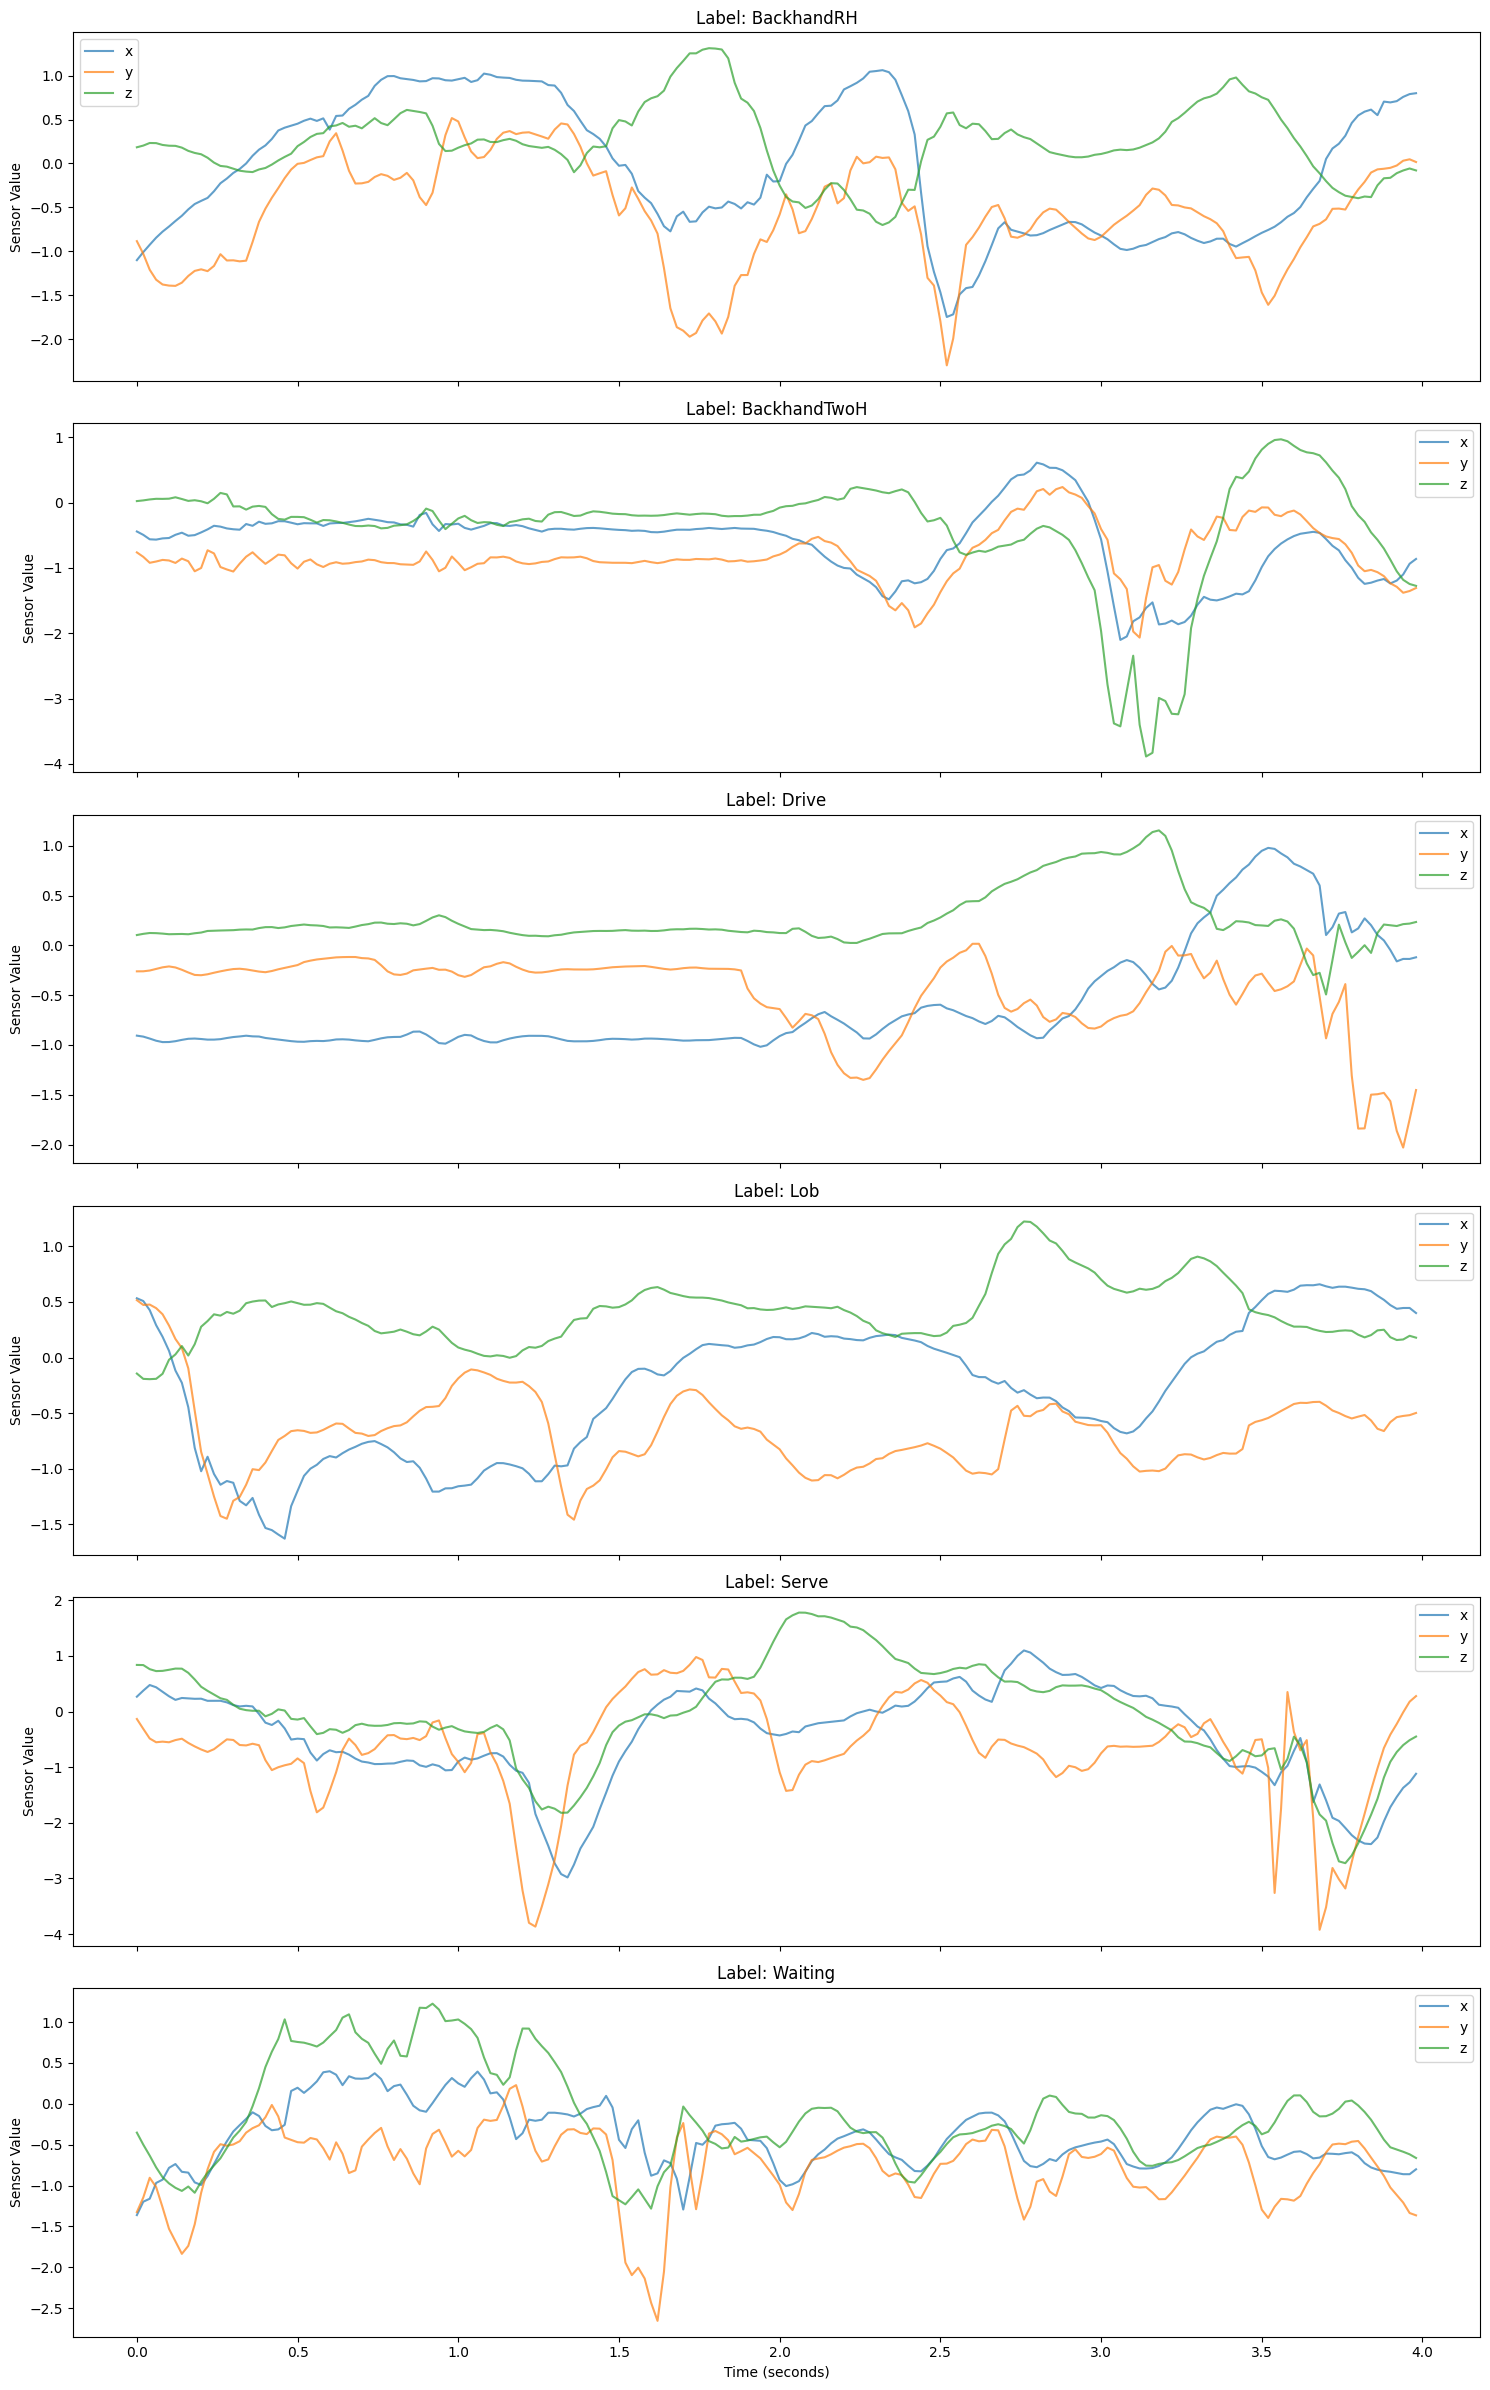

In [6]:
sample_data, sample_labels = load_sensor_data(file_path='/content/drive/MyDrive/TFM_Colab_IA/data/TFM_Corpus/Custom/P1/S1/sensor_wrist_L.csv',
    window_size=WINDOW_SIZE,
    features_per_sensor=FEATURES_PER_SENSOR)

plot_temporal_evolution(sample_data, sample_labels, window_size=WINDOW_SIZE,
    features_per_sensor=FEATURES_PER_SENSOR,
    axis_names=['x', 'y', 'z'])

In [7]:
print('X_c.shape=', X_c.shape)
print('y_c.shape=', y_c.shape)
functionals, raw_labels = compute_functionals(sample_data, sample_labels)
X_functionals, raw_labels = compute_functionals(X_c, y_c)

print('X_functionals.shape=', X_functionals.shape)
first_window = X_c[0]
print(first_window)
print('first_window.shape=', first_window.shape)
first_x_values = first_window[:, 0]
#print(first_x_values)
print('first_x_values.shape=', first_x_values.shape)
# compute the mean value of first_x_values
# Assuming your data is defined
import numpy as np
mean_val = np.mean(first_x_values)
print(mean_val)
stdev_val = np.std(first_x_values)
print(stdev_val)
# Or using the array method
mean_val = first_x_values.mean()
print(mean_val)
print(X_functionals[0])

X_c.shape= (14400, 200, 12)
y_c.shape= (14400,)
X_functionals.shape= (14400, 72)
[[ 0.99243164 -0.12939453  0.01806641 ... -0.87011719  0.11157227
   0.23974609]
 [ 0.96533203 -0.13208008  0.02099609 ... -0.86694336  0.10791016
   0.23901367]
 [ 0.95214844 -0.13500977  0.01757812 ... -0.86547852  0.09277344
   0.23510742]
 ...
 [ 1.14294434  0.09255371 -0.13682861 ... -1.66362305  1.76185303
   0.43433838]
 [ 1.12033691  0.10516357 -0.15961914 ... -1.59429932  1.57940674
   0.53118896]
 [ 1.13380127  0.11352539 -0.16241455 ... -1.64331055  1.54979248
   0.58084717]]
first_window.shape= (200, 12)
first_x_values.shape= (200,)
0.9626110745141219
0.0857264303226207
0.9626110745141219
[ 0.96261107 -0.23060336  0.01472625  0.99420394  0.02106618 -0.13876067
 -0.59929985 -0.46600639  0.264079   -0.95209964  0.36080923  0.09463864
  0.08572643  0.15238038  0.09312845  0.0810306   0.12836097  0.10783375
  0.53953321  0.4072983   0.28221486  0.73339314  0.45275262  0.73224949
  0.00734902  0.023

In [8]:
print('sample_data.shape=', sample_data.shape)
print('functionals.shape=', functionals.shape)
first_window = sample_data[0]
print(first_window)
print('first_window.shape=', first_window.shape)
first_x_values = first_window[:, 0]
#print(first_x_values)
print('first_x_values.shape=', first_x_values.shape)
# compute the mean value of first_x_values
# Assuming your data is defined
import numpy as np
mean_val = np.mean(first_x_values)
print(mean_val)
stdev_val = np.std(first_x_values)
print(stdev_val)
# Or using the array method
mean_val = first_x_values.mean()
print(mean_val)
print(functionals[0])

sample_data.shape= (360, 200, 3)
functionals.shape= (360, 18)
[[-9.06616211e-01 -2.61010742e-01  1.03515625e-01]
 [-9.16235352e-01 -2.60546875e-01  1.15454102e-01]
 [-9.35839844e-01 -2.52758789e-01  1.23901367e-01]
 [-9.57592773e-01 -2.36401367e-01  1.22387695e-01]
 [-9.71435547e-01 -2.20581055e-01  1.17944336e-01]
 [-9.70654297e-01 -2.11596680e-01  1.11694336e-01]
 [-9.62280273e-01 -2.21997070e-01  1.12988281e-01]
 [-9.49023437e-01 -2.45166016e-01  1.14306641e-01]
 [-9.38159180e-01 -2.72460938e-01  1.11401367e-01]
 [-9.35742188e-01 -2.97045898e-01  1.21435547e-01]
 [-9.40380859e-01 -2.99902344e-01  1.28466797e-01]
 [-9.46557617e-01 -2.90429687e-01  1.44531250e-01]
 [-9.46411133e-01 -2.74951172e-01  1.46948242e-01]
 [-9.41943359e-01 -2.60913086e-01  1.49047852e-01]
 [-9.30371094e-01 -2.48193359e-01  1.50317383e-01]
 [-9.20581055e-01 -2.38085938e-01  1.52416992e-01]
 [-9.14624023e-01 -2.34765625e-01  1.57714844e-01]
 [-9.07226562e-01 -2.41528320e-01  1.59619141e-01]
 [-9.13696289e-01 -2

## Baseline Classifiers Configuration Guide

This section defines the configuration dictionary (`baseline_exp_config`) to evaluate several traditional Machine Learning algorithms. These serve as a baseline to compare against our Deep Learning models.

Below is a brief explanation of each classifier, its available hyperparameters, and tips on how to tune them:

### 1. ZeroR (Dummy Classifier)
*   **Characteristics:** The simplest possible classification method. It completely ignores all input features and simply always predicts the majority class found in the training set. It is useless for actual predictions but essential for assessment: if any of your real machine learning models cannot significantly outperform ZeroR, it means the model is failing to learn any meaningful patterns from the data.
*   **Configuration:**
    *   `enabled` (bool): Set to `True` to run the assessment. It has no tunable hyperparameters as it implements a fixed strategy (`strategy='most_frequent'`).

### 2. Naive Bayes (`GaussianNB`)
*   **Characteristics:** A simple, probabilistic classifier based on applying Bayes' theorem with strong (naive) independence assumptions between the features. It is very fast, requires little tuning, and often serves as a solid "first guess" baseline.
*   **Configuration:**
    *   `enabled` (bool): Set to `True` to run the model. It has no major hyperparameters to tune in its standard Gaussian implementation.

### 3. Logistic Regression
*   **Characteristics:** A linear model used for classification. It predicts the probability of a categorical dependent variable. It is highly interpretable and performs well when the relationship between features and labels is roughly linear.
*   **Configuration (`C`, `max_iter`):**
    *   `C` (float): Inverse of regularization strength. Smaller values specify stronger regularization (helps prevent overfitting but might underfit). Larger values (e.g., `1.0`, `10.0`) give the model more freedom to fit the training data. **Tip:** Try values like `0.01`, `0.1`, `1.0`, `10.0`.
    *   `max_iter` (int): Maximum number of iterations taken for the solvers to converge. **Tip:** Keep it at `1000` or higher; if you get convergence warnings, increase this value.

### 4. Decision Tree
*   **Characteristics:** A non-linear model that splits the data into branches based on feature values to make predictions. Highly interpretable but very prone to overfitting if allowed to grow too deep.
*   **Configuration (`max_depth`):**
    *   `max_depth` (int or `None`): The maximum depth of the tree. If `None`, nodes are expanded until all leaves are pure, which usually leads to severe overfitting. **Tip:** Set a specific depth like `5`, `10`, or `15` to act as a regularization mechanism and prevent the tree from memorizing the training data.

### 5. Random Forest
*   **Characteristics:** An ensemble method that operates by constructing a multitude of decision trees at training time and outputting the mode of the classes. It is extremely robust, naturally handles non-linearities, and resists overfitting much better than a single Decision Tree.
*   **Configuration (`n_estimators`, `n_jobs`):**
    *   `n_estimators` (int): The number of trees in the forest. More trees generally improve performance but increase computational cost. **Tip:** Start with `100`. If you have the computational resources and want to squeeze out more accuracy, try `200` or `500`.
    *   `n_jobs` (int): The number of parallel jobs to run. **Tip:** Leave this at `-1` to use all available processor cores and speed up training significantly.

### 6. Support Vector Machine (SVM)
*   **Characteristics:** A powerful classifier that attempts to find the hyperplane that best separates the different classes with the maximum margin. It is highly effective in high-dimensional spaces.
*   **Configuration (`C`, `kernel`):**
    *   `C` (float): Regularization parameter. Similar to Logistic Regression, a smaller `C` creates a wider, softer margin (more tolerant to misclassifications but less prone to overfitting), while a larger `C` creates a strict, hard margin. **Tip:** Test values logarithmically, e.g., `0.1`, `1.0`, `10.0`, `100.0`.
    *   `kernel` (str): Specifies the kernel type to be used in the algorithm. `linear` is good for simple datasets, while `rbf` (Radial Basis Function) maps data to a higher-dimensional space to find non-linear boundaries. **Tip:** Start with `'rbf'`. If you suspect the classes are linearly separable or if `'rbf'` is too slow/overfitting, switch to `'linear'`.


Configuration:  {
    "ZeroR": {
        "enabled": true
    },
    "Naive Bayes": {
        "enabled": true
    },
    "Logistic Regression": {
        "enabled": true,
        "max_iter": 1000,
        "C": 1.0
    },
    "Decision Tree": {
        "enabled": true,
        "max_depth": 15
    },
    "Random Forest": {
        "enabled": true,
        "n_estimators": 200,
        "n_jobs": -1
    },
    "SVM": {
        "enabled": true,
        "C": 1.0,
        "kernel": "rbf"
    }
}

==================== BASELINE EXPERIMENT: Baseline Experiments ====================

--- Training ZeroR ---
Fold P1: 0.1667
Fold P2: 0.1667
Fold P3: 0.1667
Fold P4: 0.1667
Fold P5: 0.1667
Fold P6: 0.1667
Fold P7: 0.1667
Fold P8: 0.1667
Fold P9: 0.1667
Fold P10: 0.1667
Fold P11: 0.1667
Fold P12: 0.1667
Fold P13: 0.1667
Fold P14: 0.1667
Fold P15: 0.1667
Fold P16: 0.1667
Fold P17: 0.1667
Fold P18: 0.1667
Fold P19: 0.1667
Fold P20: 0.1667
[ZeroR] GLOBAL RESULT Media: 0.1667 ± 0.0000 (95% CI)

--- Training 

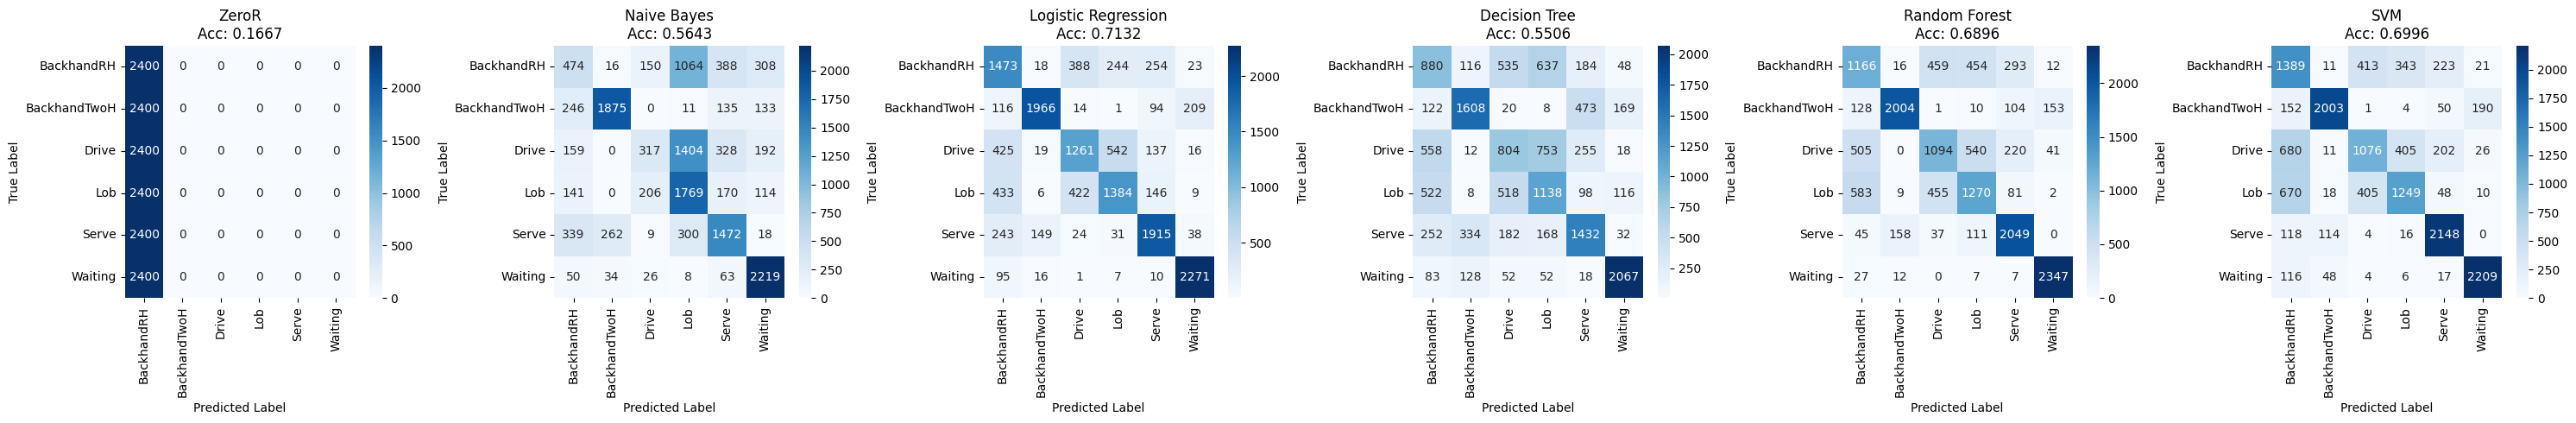


--- Classification Report: ZeroR ---
              precision    recall  f1-score   support

  BackhandRH       0.17      1.00      0.29      2400
BackhandTwoH       0.00      0.00      0.00      2400
       Drive       0.00      0.00      0.00      2400
         Lob       0.00      0.00      0.00      2400
       Serve       0.00      0.00      0.00      2400
     Waiting       0.00      0.00      0.00      2400

    accuracy                           0.17     14400
   macro avg       0.03      0.17      0.05     14400
weighted avg       0.03      0.17      0.05     14400


--- Classification Report: Naive Bayes ---
              precision    recall  f1-score   support

  BackhandRH       0.34      0.20      0.25      2400
BackhandTwoH       0.86      0.78      0.82      2400
       Drive       0.45      0.13      0.20      2400
         Lob       0.39      0.74      0.51      2400
       Serve       0.58      0.61      0.59      2400
     Waiting       0.74      0.92      0.82      2

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [9]:
import importlib
import src.models_lib
importlib.reload(src.models_lib)
from src.models_lib import run_baseline_experiment

baseline_exp_config = {
    "ZeroR": {
        "enabled": True
    },
    "Naive Bayes": {
        "enabled": True
    },
    "Logistic Regression": {
        "enabled": True,
        "max_iter": 1000,
        "C": 1.0
    },
    "Decision Tree": {
        "enabled": True,
        "max_depth": 15
    },
    "Random Forest": {
        "enabled": True,
        "n_estimators": 200,
        "n_jobs": -1
    },
    "SVM": {
        "enabled": True,
        "C": 1.0,
        "kernel": 'rbf'
    }
}

run_baseline_experiment(X_functionals, y_c, classes=VALID_CLASSES, subjects=subjects_c, title='Baseline Experiments', config=baseline_exp_config)

## BiLSTM Deep Learning Configuration Guide

This section defines the configuration dictionary (`experiment_config`) used to train our deep learning model.

### The BiLSTM Model
We employ a **Bidirectional Long Short-Term Memory (BiLSTM)** neural network. Unlike traditional models that treat data as independent points, LSTMs are specifically designed to handle sequential data (like time-series data from sensors) by maintaining an internal "memory" of past inputs. A *Bidirectional* LSTM goes a step further by processing the sequence in both forward and backward directions, allowing the network to understand context from both the past and the future at any given time step. This makes it highly effective for recognizing complex, time-dependent patterns in human activity.

### Configuration Parameters

#### 1. General Configuration (`general`)
*   **`verbose`**: Controls the amount of visual feedback during training. `0` is silent, `1` displays an animated progress bar per epoch, and `2` prints one line per epoch. **Tip:** Use `1` for interactive notebooks, or `0` if you want a clean, concise output.
*   **`window_size`**: The number of time steps (sensor readings) in each input sequence. This must match the length of the data windows extracted from the dataset.
*   **`num_features_per_step`**: The number of independent sensor channels (e.g., X, Y, Z axes for multiple sensors) recorded at each time step.

#### 2. Training Setup (`training`)
*   **`epochs`**: The absolute maximum number of times the model will pass through the entire training dataset. **Tip:** Set this relatively high (e.g., `100` or `200`) and rely on the `early_stopping` mechanism to halt training when the model stops improving.
*   **`batch_size`**: The number of data windows processed by the network before updating its internal weights. **Tip:** A smaller batch size (e.g., `16`, `32`) acts as a form of regularization and often leads to better generalization, though it trains slower. A larger batch size (`64`, `128`) trains faster but requires more memory.
*   **`validation_split`**: The fraction of the training data set aside to evaluate the loss at the end of each epoch. **Tip:** Although we are using a Leave-One-Subject-Out (LOSO) cross-validation scheme where the test set acts as our strict validation, setting validation_split to 0.1 (or 0.15, 0.2) in your config is the best practice to properly guide the training process before finally evaluating on your test subjects. If you don't use a validation split, you are forced to monitor the loss (training loss) for early stopping. The problem with this is that deep neural networks can easily memorize the training data, meaning the training loss will just keep going down forever, and early stopping won't effectively prevent overfitting.

#### 3. Early Stopping (`early_stopping`)
This is a critical regularization technique that stops training automatically when the model begins to overfit.
*   **`monitor`**: The metric to observe (usually `'val_loss'` if you have a validation split, or just `'loss'` if `validation_split=0` or if evaluating directly on the test set).
*   **`patience`**: The number of consecutive epochs with no improvement before training is terminated. **Tip:** Set this between `10` and `20`. If the learning rate is being reduced (see `reduce_lr`), ensure `early_stopping` patience is greater than `reduce_lr` patience so the model has a chance to benefit from the lower learning rate.
*   **`start_from_epoch`**: Forces the model to train for at least this many epochs before early stopping can trigger.

#### 4. Learning Rate Reduction (`reduce_lr`)
Slows down the learning process as the model gets closer to the optimal solution, helping it converge smoothly without "bouncing" around the minimum.
*   **`monitor`**: The metric to observe (usually matches early stopping).
*   **`factor`**: The multiplier applied to the learning rate. For example, `0.5` cuts the learning rate in half.
*   **`patience`**: The number of epochs with no improvement before the learning rate is reduced. **Tip:** A value between `3` and `7` usually works best. It must be strictly less than the `early_stopping` patience.
*   **`min_lr`**: The absolute lowest value the learning rate can reach to prevent the model from stopping its learning entirely.

In [10]:
# ==========================================
# EXPERIMENT CONFIGURATION
# Modify these values to easily tweak the training process
# ==========================================
experiment_config = {
    "general": {
        "verbose": 1, # verbose=1 (Visual progress): Displays an animated progress bar for each epoch, along with the loss and accuracy.
        "window_size": WINDOW_SIZE,
        "num_features_per_step": N_CHANNELS,
        "StandardScaler": False
    },
    "training": {
        "epochs": 100,
        "batch_size": 64,
        "validation_split": 0.1
    },
    "early_stopping": {
        "monitor": "val_loss",
        "patience": 5,
        "start_from_epoch": 5
    },
    "reduce_lr": {
        "monitor": "val_loss",
        "factor": 0.2,
        "patience": 3,
        "min_lr": 0.0001
    }
}

EXPERIMENTO 1: CUSTOM

Configuration:  {
    "general": {
        "verbose": 1,
        "window_size": 200,
        "num_features_per_step": 12,
        "StandardScaler": false
    },
    "training": {
        "epochs": 100,
        "batch_size": 64,
        "validation_split": 0.1
    },
    "early_stopping": {
        "monitor": "val_loss",
        "patience": 5,
        "start_from_epoch": 5
    },
    "reduce_lr": {
        "monitor": "val_loss",
        "factor": 0.2,
        "patience": 3,
        "min_lr": 0.0001
    }
}

==================== EXPERIMENT: SOLO CUSTOM ====================
Epoch 1/100
193/193 ━━━━━━━━━━━━━━━━━━━━ 18s 41ms/step - accuracy: 0.3640 - loss: 1.7860 - val_accuracy: 0.5358 - val_loss: 1.3373 - learning_rate: 0.0010
Epoch 2/100
193/193 ━━━━━━━━━━━━━━━━━━━━ 8s 43ms/step - accuracy: 0.5894 - loss: 1.1994 - val_accuracy: 0.3589 - val_loss: 1.6234 - learning_rate: 0.0010
Epoch 3/100
193/193 ━━━━━━━━━━━━━━━━━━━━ 8s 39ms/step - accuracy: 0.6697 - loss: 0.9710 - val_accuracy: 0.5782 - 

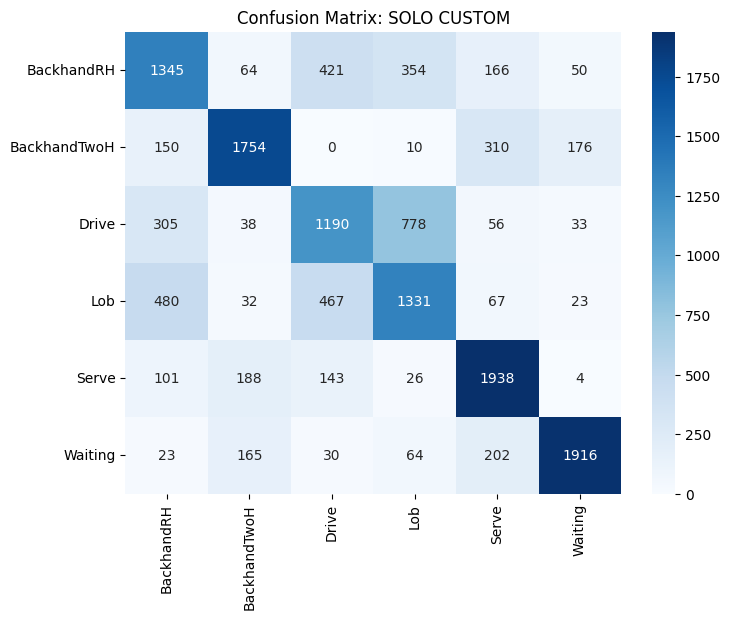

              precision    recall  f1-score   support

  BackhandRH       0.56      0.56      0.56      2400
BackhandTwoH       0.78      0.73      0.76      2400
       Drive       0.53      0.50      0.51      2400
         Lob       0.52      0.55      0.54      2400
       Serve       0.71      0.81      0.75      2400
     Waiting       0.87      0.80      0.83      2400

    accuracy                           0.66     14400
   macro avg       0.66      0.66      0.66     14400
weighted avg       0.66      0.66      0.66     14400



In [ ]:
import importlib
importlib.reload(src.models_lib)
from src.models_lib import run_experiment
run_experiment(X_c, y_c, classes=VALID_CLASSES, subjects=subjects_c, title="SOLO CUSTOM", config=experiment_config)

EXPERIMENTO 2: COMMERCIAL

	[Loading dataset from /content/drive/MyDrive/TFM_Colab_IA/data/TFM_Corpus/Commercial]
		[Processing subject: P1]
			[Processing session: S1]
			[Processing session: S2]
		[Processing subject: P2]
			[Processing session: S1]
			[Processing session: S2]
		[Processing subject: P3]
			[Processing session: S1]
			[Processing session: S2]
		[Processing subject: P4]
			[Processing session: S1]
			[Processing session: S2]
		[Processing subject: P5]
			[Processing session: S1]
			[Processing session: S2]
		[Processing subject: P6]
			[Processing session: S1]
			[Processing session: S2]
		[Processing subject: P7]
			[Processing session: S1]
			[Processing session: S2]
		[Processing subject: P8]
			[Processing session: S1]
			[Processing session: S2]
		[Processing subject: P9]
			[Processing session: S1]
			[Processing session: S2]
		[Processing subject: P10]
			[Processing session: S1]
			[Processing session: S2]
		[Processing subject: P11]
			[Processing session: S1]
			[Processing session: S2

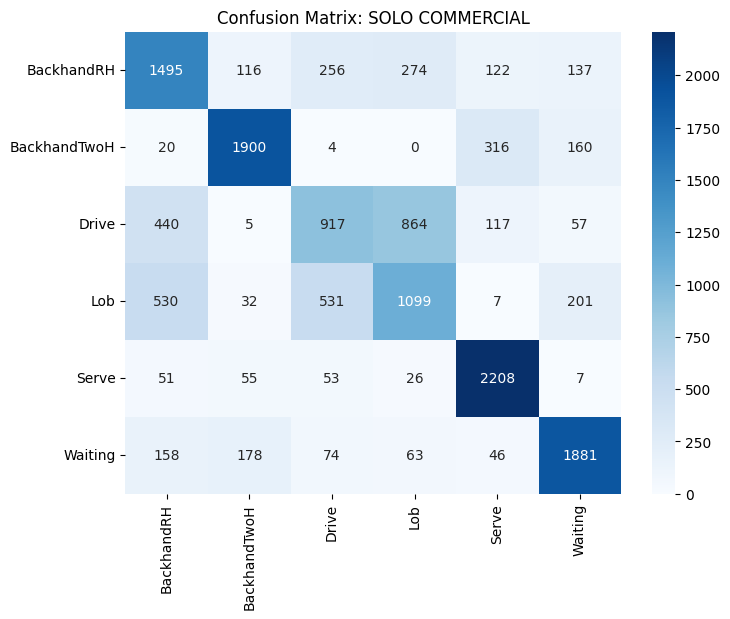

              precision    recall  f1-score   support

  BackhandRH       0.55      0.62      0.59      2400
BackhandTwoH       0.83      0.79      0.81      2400
       Drive       0.50      0.38      0.43      2400
         Lob       0.47      0.46      0.47      2400
       Serve       0.78      0.92      0.85      2400
     Waiting       0.77      0.78      0.78      2400

    accuracy                           0.66     14400
   macro avg       0.65      0.66      0.65     14400
weighted avg       0.65      0.66      0.65     14400



In [ ]:
path_comm = [os.path.join(CORPUS_PATH, 'Commercial')]

X_m, y_m, sub_m = load_dataset(
    base_paths=path_comm,
    sensors_list=SENSORS_LIST,
    valid_labels=VALID_CLASSES,
    window_size=WINDOW_SIZE,
    features_per_sensor=FEATURES_PER_SENSOR
)

run_experiment(
    X=X_m,
    y=y_m,
    classes=VALID_CLASSES,
    subjects=sub_m,
    title="SOLO COMMERCIAL",
    config=experiment_config
)

EXPERIMENTO 3: TOTAL

In [ ]:
import os
from src.dataset_lib import load_dataset
from src.models_lib import run_experiment_dual_test

# Rutas separadas
path_custom = [os.path.join(CORPUS_PATH, 'Custom')]
path_comm = [os.path.join(CORPUS_PATH, 'Commercial')]

print("Cargando base de datos Custom...")
X_custom, y_custom, sub_custom = load_dataset(
    path_custom, SENSORS_LIST, VALID_CLASSES, WINDOW_SIZE, FEATURES_PER_SENSOR
)

print("Cargando base de datos Comercial...")
X_comm, y_comm, sub_comm = load_dataset(
    path_comm, SENSORS_LIST, VALID_CLASSES, WINDOW_SIZE, FEATURES_PER_SENSOR
)

my_config = {
    "general": {
        "verbose": 1,
        "window_size": WINDOW_SIZE,
        "num_features_per_step": FEATURES_PER_SENSOR * len(SENSORS_LIST),
        "StandardScaler": False
    },
    "training": {
        "epochs": 100,
        "batch_size": 64
    },
    "early_stopping": {
        "monitor": "val_loss",
        "patience": 5,
        "start_from_epoch": 5
    },
    "reduce_lr": {
        "monitor": "val_loss",
        "factor": 0.2,
        "patience": 3,
        "min_lr": 0.0001
    }
}

# Lanzar experimento dual
run_experiment_dual_test(
    X_c=X_custom, y_c=y_custom, sub_c=sub_custom,
    X_com=X_comm, y_com=y_comm, sub_com=sub_comm,
    classes=VALID_CLASSES,
    title='Exp 3: Entrenamiento Total, Testeo Aislado',
    config=my_config
)

Cargando base de datos Custom...
	[Loading dataset from /content/drive/MyDrive/TFM_Colab_IA/data/TFM_Corpus/Custom]
		[Processing subject: P1]
			[Processing session: S1]
			[Processing session: S2]
		[Processing subject: P2]
			[Processing session: S1]
			[Processing session: S2]
		[Processing subject: P3]
			[Processing session: S1]
			[Processing session: S2]
		[Processing subject: P4]
			[Processing session: S1]
			[Processing session: S2]
		[Processing subject: P5]
			[Processing session: S1]
			[Processing session: S2]
		[Processing subject: P6]
			[Processing session: S1]
			[Processing session: S2]
		[Processing subject: P7]
			[Processing session: S1]
			[Processing session: S2]
		[Processing subject: P8]
			[Processing session: S1]
			[Processing session: S2]
		[Processing subject: P9]
			[Processing session: S1]
			[Processing session: S2]
		[Processing subject: P10]
			[Processing session: S1]
			[Processing session: S2]
		[Processing subject: P11]
			[Processing session: S

ENTRENAMIENTO FINAL Y EXPORTACIÓN

In [ ]:
import os
import numpy as np
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from src.models_lib import create_bilstm_model

print("Entrenando modelo final de producción con dataset TOTAL...")

print("Cargando base de datos TOTAL...")
paths_all = [os.path.join(CORPUS_PATH, 'Custom'), os.path.join(CORPUS_PATH, 'Commercial')]
X_t, y_t, sub_t = load_dataset(
    base_paths=paths_all,
    sensors_list=SENSORS_LIST,
    valid_labels=VALID_CLASSES,
    window_size=WINDOW_SIZE,
    features_per_sensor=FEATURES_PER_SENSOR
)

# Codificación de etiquetas
le_final = LabelEncoder().fit(VALID_CLASSES)
y_enc_t = le_final.transform(y_t)

# Creación del modelo
num_features = FEATURES_PER_SENSOR * len(SENSORS_LIST)
model_final = create_bilstm_model(
    num_time_steps=WINDOW_SIZE,
    num_features_per_step=num_features,
    num_output_classes=len(VALID_CLASSES)
)

# Callbacks de EarlyStopping y ReduceLROnPlateau
early_stop_final = EarlyStopping(
    monitor='loss',
    min_delta=0.005,
    patience=5,
    restore_best_weights=True,
    start_from_epoch=15
)

reduce_lr_final = ReduceLROnPlateau(
    monitor='loss',
    factor=0.5,
    patience=3,
    min_lr=0.0001,
    verbose=1
)

# Ejecución del entrenamiento
model_final.fit(
    X_t,
    y_enc_t,
    epochs=100,
    batch_size=64,
    verbose=1,
    callbacks=[early_stop_final, reduce_lr_final]
)

# Exportación de archivos para la Raspberry Pi
model_filename = "modelo_tenis_v2_final"
with open(f"{model_filename}.json", "w") as f:
    f.write(model_final.to_json())
model_final.save_weights(f"{model_filename}.weights.h5")

print(f"\n--- EXPORTACIÓN COMPLETADA ---")

Entrenando modelo final de producción con dataset TOTAL...
Cargando base de datos TOTAL...
	[Loading dataset from /content/drive/MyDrive/TFM_Colab_IA/data/TFM_Corpus/Custom]
		[Processing subject: P1]
			[Processing session: S1]
			[Processing session: S2]
		[Processing subject: P2]
			[Processing session: S1]
			[Processing session: S2]
		[Processing subject: P3]
			[Processing session: S1]
			[Processing session: S2]
		[Processing subject: P4]
			[Processing session: S1]
			[Processing session: S2]
		[Processing subject: P5]
			[Processing session: S1]
			[Processing session: S2]
		[Processing subject: P6]
			[Processing session: S1]
			[Processing session: S2]
		[Processing subject: P7]
			[Processing session: S1]
			[Processing session: S2]
		[Processing subject: P8]
			[Processing session: S1]
			[Processing session: S2]
		[Processing subject: P9]
			[Processing session: S1]
			[Processing session: S2]
		[Processing subject: P10]
			[Processing session: S1]
			[Processing session:

EXPERIMENTO 4: ABLACIÓN

In [11]:
import itertools
import os
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from src.dataset_lib import load_dataset
from src.models_lib import create_bilstm_model

def run_fast_ablation_study(X, y, subjects):
    print(f"\n{'='*20} ESTUDIO DE ABLACIÓN (ZERO-MASKING) {'='*20}")
    print("Entrenando 1 vez por pliegue. Evaluando 15 combinaciones...\n")

    le = LabelEncoder().fit(VALID_CLASSES)
    y_enc = le.transform(y)
    unique_subs = np.unique(subjects)

    # Mapa de qué canales pertenecen a qué sensor
    sensor_indices = {
        'chest': [0, 1, 2],
        'waist': [3, 4, 5],
        'wrist_L': [6, 7, 8],
        'wrist_R': [9, 10, 11]
    }

    # Generar las 15 combinaciones posibles de los 4 sensores (tamaños 1, 2, 3 y 4)
    all_combinations = []
    for r in range(1, len(SENSORS_LIST) + 1):
        all_combinations.extend(list(itertools.combinations(SENSORS_LIST, r)))

    # Diccionario para acumular los aciertos de cada combinación
    ablation_results = {comb: [] for comb in all_combinations}

    # Configuración estricta de control (Evita overfitting por falta de normalización)
    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        start_from_epoch=5
    )

    reduce_lr = ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,
        patience=3,
        min_lr=0.0001,
        verbose=0
    )

    # Cálculo dinámico del número de canales por paso temporal
    num_features_per_step = FEATURES_PER_SENSOR * len(SENSORS_LIST)

    for test_sub in unique_subs:
        print(f"--- FOLD P{test_sub+1} ---")

        # Split estándar (Leave-One-Subject-Out)
        X_train, y_train = X[subjects != test_sub], y_enc[subjects != test_sub]
        X_test, y_test = X[subjects == test_sub], y_enc[subjects == test_sub]

        # Entrenar el modelo una vez con todos los sensores activos
        model = create_bilstm_model(
            num_time_steps=WINDOW_SIZE,
            num_features_per_step=num_features_per_step,
            num_output_classes=len(VALID_CLASSES)
        )

        history = model.fit(
            X_train, y_train,
            epochs=100,
            batch_size=64,
            verbose=0,
            validation_split=0.1,
            callbacks=[early_stop, reduce_lr]
        )

        # Extraemos el número de épocas reales ejecutadas
        epocas_ejecutadas = len(history.history['loss'])
        print(f"    Modelo maestro convergido en {epocas_ejecutadas} épocas.")

        # Testear todas las combinaciones mediante enmascaramiento (Zero-Masking)
        print("    Resultados de ablación parciales:")
        for comb in all_combinations:
            # Copia profunda de los datos de test del pliegue actual
            X_test_masked = np.copy(X_test)

            # Identificamos qué sensores NO están en esta combinación y los apagamos a 0
            sensors_to_zero = [s for s in SENSORS_LIST if s not in comb]
            for s in sensors_to_zero:
                idx = sensor_indices[s]
                # Ponemos a 0 todo el eje temporal de esos canales específicos
                X_test_masked[:, :, idx] = 0.0

            # Predecimos con la señal enmascarada
            preds = np.argmax(model.predict(X_test_masked, verbose=0), axis=1)
            acc = accuracy_score(y_test, preds)

            # Guardamos el resultado
            ablation_results[comb].append(acc)

            sensores_activos = " + ".join(comb)
            marker = "⭐" if len(comb) == 4 else "  "
            print(f"      {marker} [{acc:.4f}] -> {sensores_activos}")

        print("-" * 40)

    # Reporte final global
    print("\n" + "="*50)
    print("RANKING DEL ESTUDIO DE ABLACIÓN (Precisión Media)")
    print("="*50)

    ranking = []
    for comb, accs in ablation_results.items():
        ranking.append((comb, np.mean(accs)))

    # Ordenamos de mayor a menor precisión
    ranking.sort(key=lambda x: x[1], reverse=True)

    # Imprimimos los resultados ordenados
    for i, (comb, acc) in enumerate(ranking):
        sensores = " + ".join(comb)
        marker = "⭐" if len(comb) == 4 else "  "
        print(f"{i+1:02d}. {marker} [{acc:.4f}] -> {sensores}")

# --- Bloque de ejecución principal ---
print("Cargando datos totales para la ablación...")
paths_all = [os.path.join(CORPUS_PATH, 'Custom'), os.path.join(CORPUS_PATH, 'Commercial')]

# Carga correcta utilizando los 5 parámetros requeridos por tu interfaz
X_t, y_t, sub_t = load_dataset(
    base_paths=paths_all,
    sensors_list=SENSORS_LIST,
    valid_labels=VALID_CLASSES,
    window_size=WINDOW_SIZE,
    features_per_sensor=FEATURES_PER_SENSOR
)

# Ejecutamos el estudio sobre el dataset integrado
run_fast_ablation_study(X_t, y_t, sub_t)

Cargando datos totales para la ablación...
	[Loading dataset from /content/drive/MyDrive/TFM_Colab_IA/data/TFM_Corpus/Custom]
		[Processing subject: P1]
			[Processing session: S1]
			[Processing session: S2]
		[Processing subject: P2]
			[Processing session: S1]
			[Processing session: S2]
		[Processing subject: P3]
			[Processing session: S1]
			[Processing session: S2]
		[Processing subject: P4]
			[Processing session: S1]
			[Processing session: S2]
		[Processing subject: P5]
			[Processing session: S1]
			[Processing session: S2]
		[Processing subject: P6]
			[Processing session: S1]
			[Processing session: S2]
		[Processing subject: P7]
			[Processing session: S1]
			[Processing session: S2]
		[Processing subject: P8]
			[Processing session: S1]
			[Processing session: S2]
		[Processing subject: P9]
			[Processing session: S1]
			[Processing session: S2]
		[Processing subject: P10]
			[Processing session: S1]
			[Processing session: S2]
		[Processing subject: P11]
			[Processing 